# Log-Log Illusion

Generate one side-by-side figure comparing linear and log-log views of the same non-power-law dataset.

---
Filipe Borges
f3l5p7@yahoo.com.br


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


In [2]:
rng = np.random.default_rng(42)
N = 300
x = np.logspace(0, 4, N)
y_true = x**2 + x + 100.0
noise = rng.normal(loc=0.0, scale=0.08 * y_true)
y_noisy = np.clip(y_true + noise, 1e-6, None)

# Minimal sanity checks for reproducibility and log safety
assert np.all(x > 0), "x must be strictly positive for log scaling."
assert np.all(y_noisy > 0), "y_noisy must be strictly positive for log scaling."


PosixPath('/Users/filipeborges/Documents/GitHub/everyLogIsLine/assets/loglog_vs_linear.png')

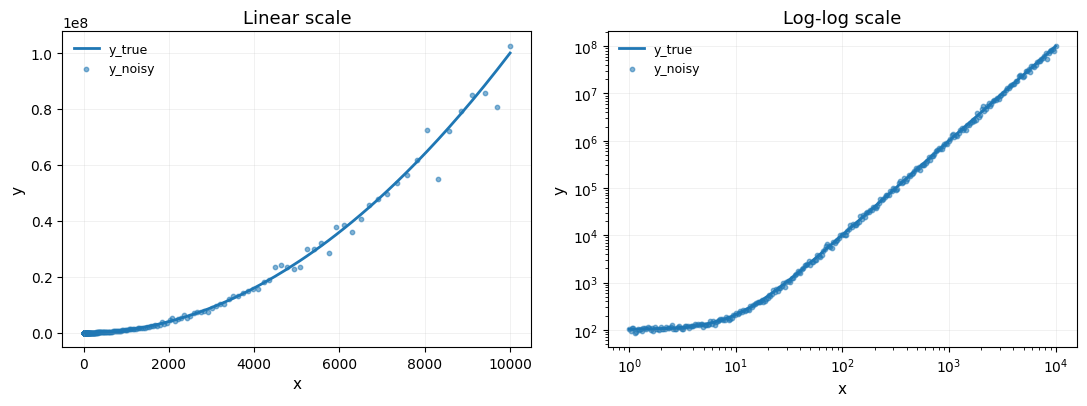

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(x, y_true, linewidth=2, label="y_true")
axes[0].scatter(x, y_noisy, s=10, alpha=0.55, label="y_noisy")
axes[0].set_title("Linear scale")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(alpha=0.2, linewidth=0.6)
axes[0].legend(frameon=False, fontsize=9)

axes[1].plot(x, y_true, linewidth=2, label="y_true")
axes[1].scatter(x, y_noisy, s=10, alpha=0.55, label="y_noisy")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Log-log scale")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].grid(alpha=0.2, linewidth=0.6)
axes[1].legend(frameon=False, fontsize=9)

fig.tight_layout()

cwd = Path.cwd().resolve()
if (cwd / "assets").exists():
    assets_dir = cwd / "assets"
elif (cwd.parent / "assets").exists():
    assets_dir = cwd.parent / "assets"
else:
    assets_dir = cwd / "assets"

assets_dir.mkdir(parents=True, exist_ok=True)
output_path = assets_dir / "loglog_vs_linear.png"
fig.savefig(output_path, dpi=300, facecolor="white")
output_path


In [4]:
plt.show()
